1) Import & Set Up

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from google.cloud import bigquery
import plotly.express as px
import plotly.graph_objects as go
import backtrader as bt

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('dark_background')
sns.set_style('darkgrid')

client = bigquery.Client()

def show(df, n=5):
    display(df.head(n))

print("Block 1 complete — imports and setup done")


Block 1 complete — imports and setup done


2) Load Data

In [15]:
tickers = [
    'AAPL','MSFT','GOOGL','AMZN','TSLA',
    'META','NVDA','INTC','AMD','NFLX',
    'PYPL','ADBE','CSCO'
]

df = client.list_rows("rugged-night-472112-i7.xnas_dataset.xnas_live_data").to_dataframe()
df = df[df['symbol'].isin(tickers)]
df = df.drop_duplicates(subset=['symbol','start_timestamp'])
df = df.dropna(subset=['close','start_timestamp'])
df['start_timestamp'] = pd.to_datetime(df['start_timestamp'], utc=True)

show(df)
print(f"Block 2 complete — data loaded and cleaned for a selected set of {len(tickers)} tickers from NASDAQ")


,exchange,symbol,event_type,volume,accumulated_volume,official_open_price,vwap,open,close,high,low,aggregate_vwap,average_size,start_timestamp,end_timestamp,ingestion_time
34,XNAS,META,AM,18327.0000,14619014.0000,632.3100,639.2454,639.0584,639.2900,639.3900,638.9045,634.4974,23.0000,2025-11-05 19:09:00+00:00,2025-11-05 19:10:00+00:00,2025-11-05 19:31:40.872448+00:00
45,XNAS,AAPL,AM,153673.0000,20289040.0000,268.6100,270.9009,270.8100,270.8500,271.0600,270.7305,269.4937,81.0000,2025-11-05 19:12:00+00:00,2025-11-05 19:13:00+00:00,2025-11-05 19:31:59.248892+00:00
69,XNAS,PYPL,AM,10731.0000,9329215.0000,66.0200,67.6629,67.6400,67.6950,67.6980,67.6400,67.3372,67.0000,2025-11-05 19:14:00+00:00,2025-11-05 19:15:00+00:00,2025-11-05 19:32:33.759546+00:00
70,XNAS,PYPL,AM,10542.0000,9339757.0000,66.0200,67.7031,67.7000,67.7300,67.7300,67.6950,67.3376,54.0000,2025-11-05 19:15:00+00:00,2025-11-05 19:16:00+00:00,2025-11-05 19:32:33.841759+00:00
72,XNAS,MSFT,AM,32942.0000,11924150.0000,513.3000,508.5371,508.4345,508.6800,508.6800,508.4100,510.4876,36.0000,2025-11-05 19:14:00+00:00,2025-11-05 19:15:00+00:00,2025-11-05 19:32:45.417829+00:00


Block 2 complete — data loaded and cleaned for a selected set of 13 tickers from NASDAQ


3) Basic Stats & EDA

Data points per ticker:


,symbol,data_points
0,AAPL,5858
1,ADBE,4360
2,AMD,6781
3,AMZN,6471
4,CSCO,4406


Basic statistics per ticker:


,symbol,mean,min,max,volatility
0,AAPL,263.0499,244.2400,277.6500,8.6524
1,ADBE,342.4691,323.2800,368.0000,10.3056
2,AMD,249.5819,223.5000,266.6925,10.7156
3,AMZN,228.9906,211.1400,258.3640,13.2335
4,CSCO,71.6767,68.5200,74.8400,1.4669


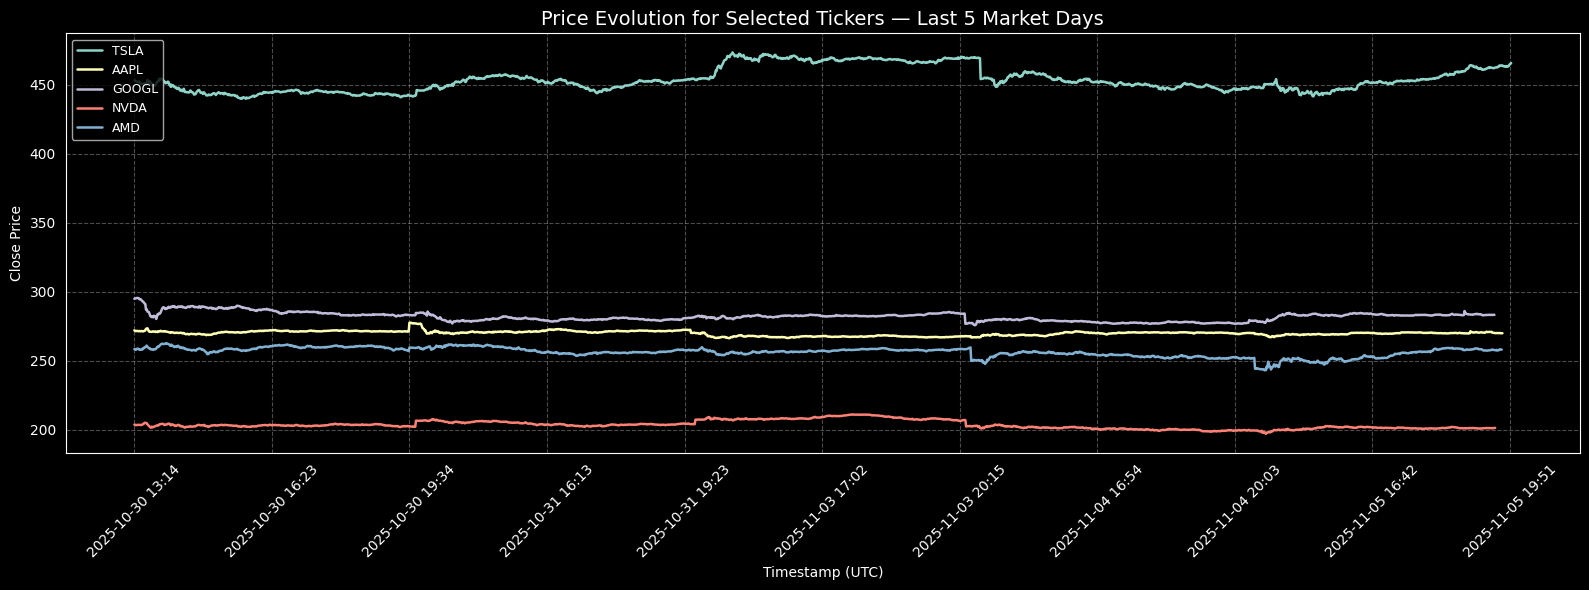

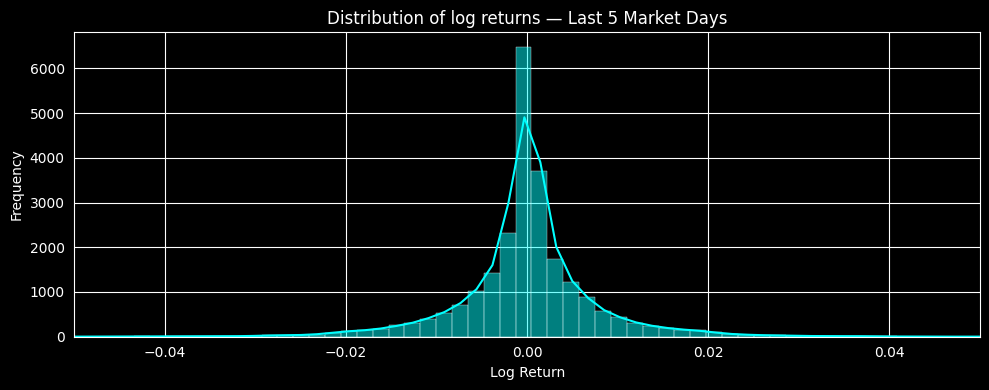

✅ Block 3 complete — last 5 days plotted


In [33]:
tickers_count = df.groupby('symbol')['start_timestamp'].count().reset_index().rename(columns={'start_timestamp':'data_points'})
print("Data points per ticker:")
show(tickers_count)

stats = df.groupby('symbol')['close'].agg(['mean','min','max','std']).reset_index().rename(columns={'std':'volatility'})
print("Basic statistics per ticker:")
show(stats)

df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1))
df['log_return'] = df['log_return'].fillna(0)

plt.style.use("dark_background")
plt.figure(figsize=(16,6))

df['date_only'] = df['start_timestamp'].dt.date
last_5_days = sorted(df['date_only'].unique())[-5:]
df_recent = df[df['date_only'].isin(last_5_days)]

for ticker in tickers:
    sample = df_recent[df_recent["symbol"] == ticker].sort_values("start_timestamp").drop_duplicates("start_timestamp")
    sample = sample.dropna(subset=["close", "start_timestamp"])

    y_values = sample["close"].values
    x_values = range(len(y_values))
    plt.plot(x_values, y_values, label=ticker, linewidth=1.8)

ref_ticker = tickers[0]
ref_sample = df_recent[df_recent["symbol"] == ref_ticker].sort_values("start_timestamp").drop_duplicates("start_timestamp")
x_ticks_idx = range(0, len(ref_sample), max(1, len(ref_sample)//10))
x_ticks_labels = [ref_sample["start_timestamp"].iloc[idx].strftime('%Y-%m-%d %H:%M') for idx in x_ticks_idx]

plt.xticks(x_ticks_idx, x_ticks_labels, rotation=45, color="white")
plt.yticks(color="white")
plt.grid(True, linestyle="--", alpha=0.3)
plt.title("Price Evolution for Selected Tickers — Last 5 Market Days", color="white", fontsize=14)
plt.xlabel("Timestamp (UTC)", color="white")
plt.ylabel("Close Price", color="white")
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df_recent['log_return'], bins=200, kde=True, color='cyan')
plt.title("Distribution of log returns — Last 5 Market Days")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.xlim(-0.05,0.05)
plt.tight_layout()
plt.show()

print("✅ Block 3 complete — last 5 days plotted")



4) Returns & Indicators

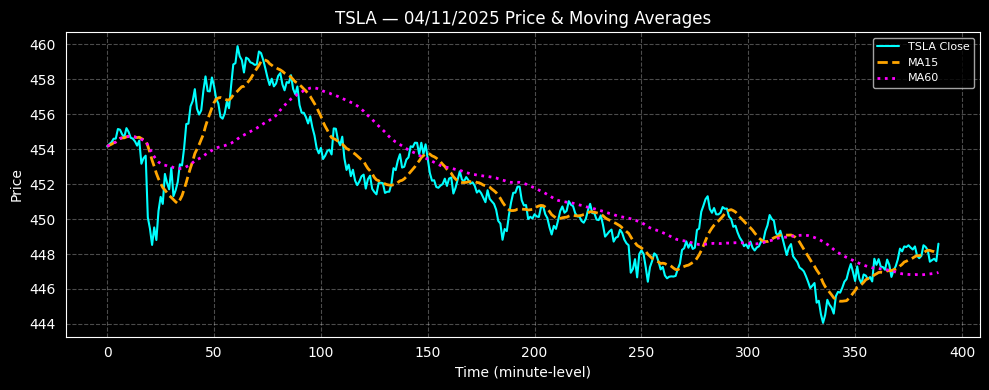

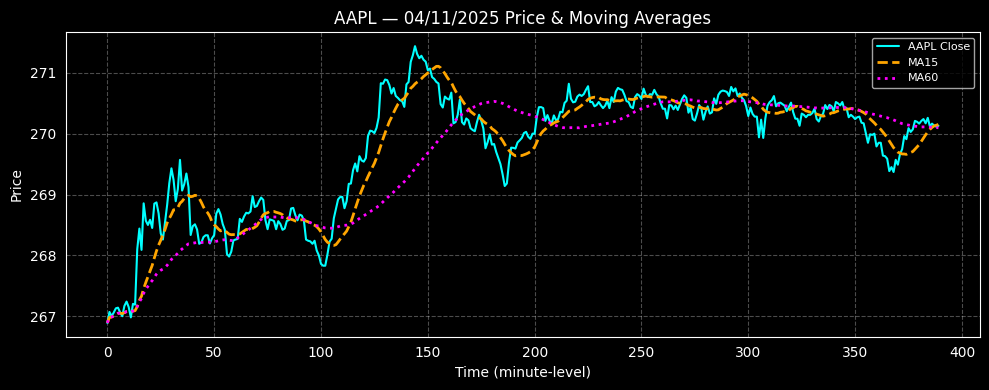

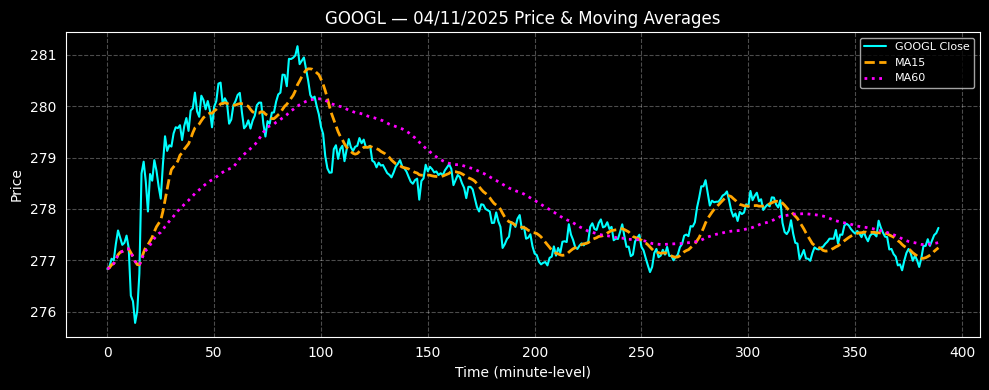

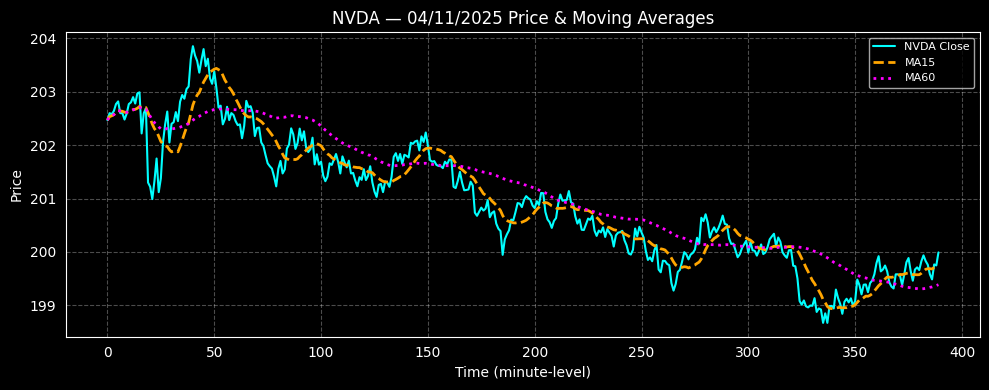

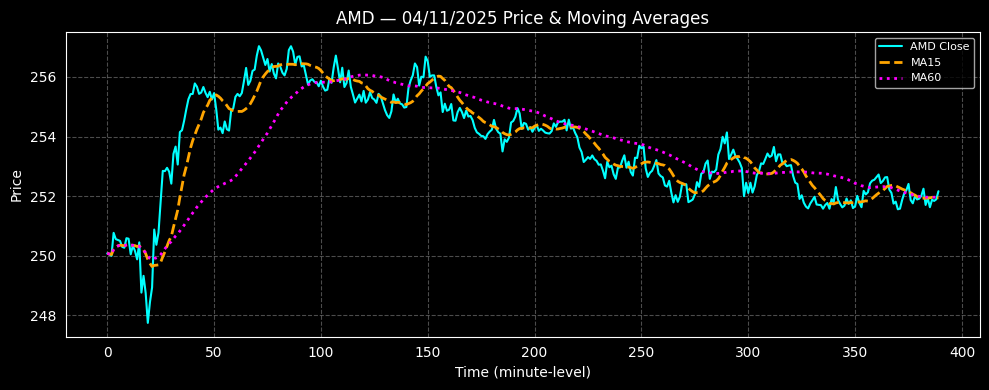

✅ Block 4 complete — data for 04/11/2025 with emphasized moving averages


In [46]:
window_short = 15
window_long = 60
tickers = ["TSLA", "AAPL", "GOOGL", "NVDA", "AMD"]

df['log_return'] = df.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1))).fillna(0)

plt.style.use("dark_background")

target_date = pd.to_datetime("2025-11-04").date()

for ticker in tickers:
    sample = df[(df["symbol"] == ticker) & (df["start_timestamp"].dt.date == target_date)]
    sample = sample.sort_values("start_timestamp").drop_duplicates("start_timestamp")
    sample = sample.dropna(subset=["close"])
    
    sample['ma_short'] = sample['close'].rolling(window=window_short, min_periods=1).mean()
    sample['ma_long'] = sample['close'].rolling(window=window_long, min_periods=1).mean()
    
    sample['signal'] = 0
    sample.iloc[window_long:, sample.columns.get_loc('signal')] = np.where(
        sample['ma_short'].iloc[window_long:] > sample['ma_long'].iloc[window_long:], 1, -1
    )

    plt.figure(figsize=(10,4))
    plt.plot(sample['close'].values, label=f"{ticker} Close", linewidth=1.5, color="cyan")
    plt.plot(sample['ma_short'].values, linestyle='--', label=f"MA{window_short}", linewidth=2, color="orange")
    plt.plot(sample['ma_long'].values, linestyle=':', label=f"MA{window_long}", linewidth=2, color="magenta")
    plt.title(f"{ticker} — 04/11/2025 Price & Moving Averages", color="white", fontsize=12)
    plt.xlabel("Time (minute-level)", color="white")
    plt.ylabel("Price", color="white")
    plt.legend(fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("✅ Block 4 complete — data for 04/11/2025 with emphasized moving averages")





5) Simple Strategy 1: Moving Average Crossover

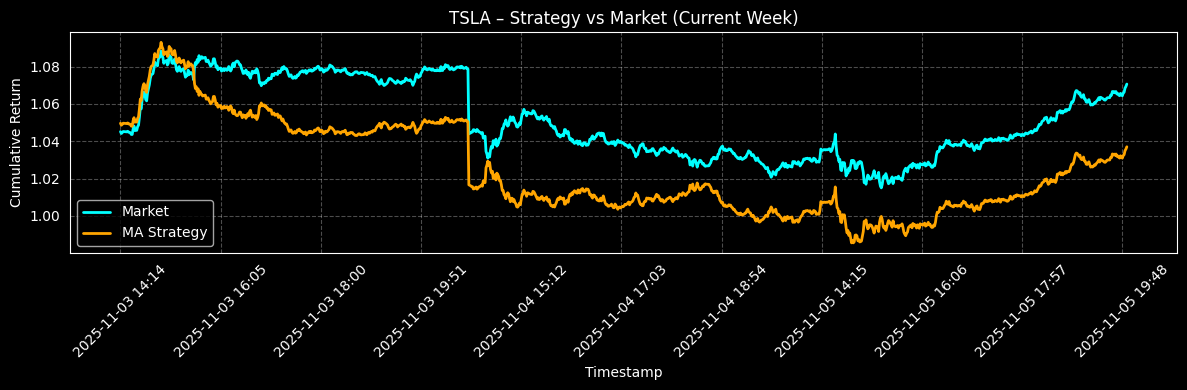

In [51]:
sample = df[df["symbol"] == ticker].sort_values("start_timestamp").drop_duplicates("start_timestamp").copy()
sample = sample.dropna(subset=["close"])

window_short = 15
window_long = 60

sample['ma_short'] = sample['close'].rolling(window=window_short, min_periods=1).mean()
sample['ma_long'] = sample['close'].rolling(window=window_long, min_periods=1).mean()

sample['signal'] = 0
sample.iloc[window_long:, sample.columns.get_loc('signal')] = np.where(
    sample['ma_short'].iloc[window_long:] > sample['ma_long'].iloc[window_long:], 1, -1
)

sample['return'] = sample['close'].pct_change().fillna(0)
sample['strategy_return'] = sample['signal'].shift(1) * sample['return']

sample['cumulative_strategy'] = (1 + sample['strategy_return']).cumprod()
sample['cumulative_market'] = (1 + sample['return']).cumprod()

# Limit to last 5 days for readability
last_5_days = sample['start_timestamp'].max() - pd.Timedelta(days=5)
sample_recent = sample[sample['start_timestamp'] >= last_5_days]

plt.style.use("dark_background")
plt.figure(figsize=(12,4))
plt.plot(sample_recent['cumulative_market'].values, label='Market', color='cyan', linewidth=2)
plt.plot(sample_recent['cumulative_strategy'].values, label='MA Strategy', color='orange', linewidth=2)

x_labels = sample_recent['start_timestamp'].dt.strftime('%Y-%m-%d %H:%M')
x_ticks = range(0, len(x_labels), max(1, len(x_labels)//10))
plt.xticks(x_ticks, x_labels.iloc[x_ticks], rotation=45, color='white')

plt.yticks(color='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.title(f"{ticker} – Strategy vs Market (Current Week)", color='white')
plt.xlabel("Timestamp", color='white')
plt.ylabel("Cumulative Return", color='white')
plt.legend()
plt.tight_layout()
plt.show()


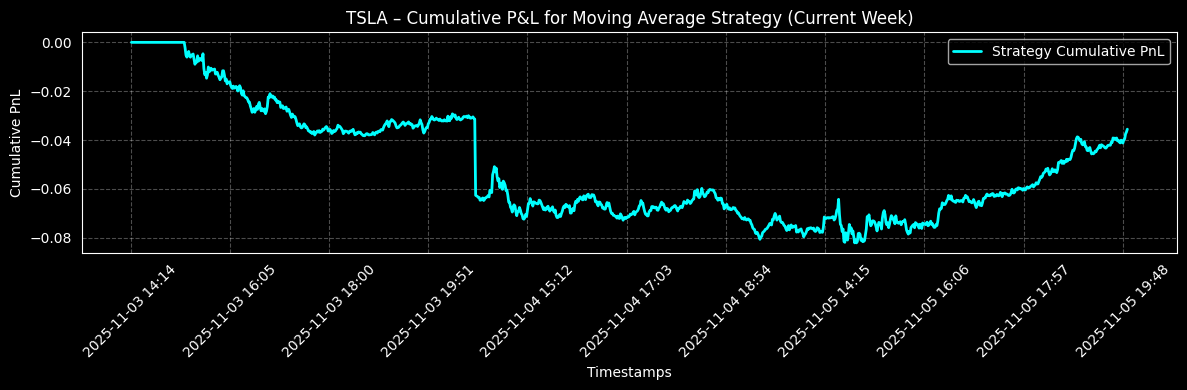

In [49]:
ticker = "TSLA"
window_short = 10
window_long = 60

sample = df[df["symbol"]==ticker].sort_values("start_timestamp").drop_duplicates("start_timestamp")
sample = sample.dropna(subset=["close", "start_timestamp"])

# Sélection des 5 derniers jours
sample_recent = sample[sample['start_timestamp'] >= (sample['start_timestamp'].max() - pd.Timedelta(days=5))].copy()

sample_recent['ma_short'] = sample_recent['close'].rolling(window=window_short, min_periods=1).mean()
sample_recent['ma_long']  = sample_recent['close'].rolling(window=window_long, min_periods=1).mean()

# Initialisation du signal
sample_recent['signal'] = 0
# Attention ici : on utilise .iloc pour les positions
sample_recent.iloc[window_long:, sample_recent.columns.get_loc('signal')] = np.where(
    sample_recent['ma_short'].iloc[window_long:] > sample_recent['ma_long'].iloc[window_long:], 1, -1
)

# Calcul du retour et P&L
sample_recent['return'] = sample_recent['close'].pct_change().fillna(0)
sample_recent['strategy_return'] = sample_recent['signal'].shift(1) * sample_recent['return']
sample_recent['cumulative_pnl'] = (1 + sample_recent['strategy_return']).cumprod() - 1

# Plot
plt.style.use("dark_background")
plt.figure(figsize=(12,4))
plt.plot(sample_recent['cumulative_pnl'].values, color='cyan', linewidth=2, label='Strategy Cumulative PnL')
plt.title(f"{ticker} – Cumulative P&L for Moving Average Strategy (Current Week)", color='white')
plt.xlabel("Timestamps")
plt.ylabel("Cumulative PnL")
plt.grid(True, linestyle='--', alpha=0.3)
x_labels = sample_recent['start_timestamp'].dt.strftime('%Y-%m-%d %H:%M')
x_ticks = range(0, len(x_labels), max(1, len(x_labels)//10))
plt.xticks(x_ticks, x_labels.iloc[x_ticks], rotation=45, color='white')

plt.yticks(color='white')
plt.legend()
plt.tight_layout()
plt.show()


The moving average strategy underperformed on Tesla this week because the price experienced sharp swings that repeatedly crossed the moving averages. 

Early in the week, the price spike above 473 triggered short-term signals that were quickly reversed as the price dropped, causing the strategy to take losing positions. During the midweek plateau and subsequent decline, the signals lagged the rapid price movements, amplifying losses and pushing the cumulative P&L down to -0.08. As the price gradually recovered toward 460, the strategy was able to partially capture the upward trend, recovering some value and ending the week around -0.04. 


This illustrates a key limitation of simple moving average strategies in highly volatile markets: they can generate delayed or whipsaw signals that erode performance despite an overall favorable price move.


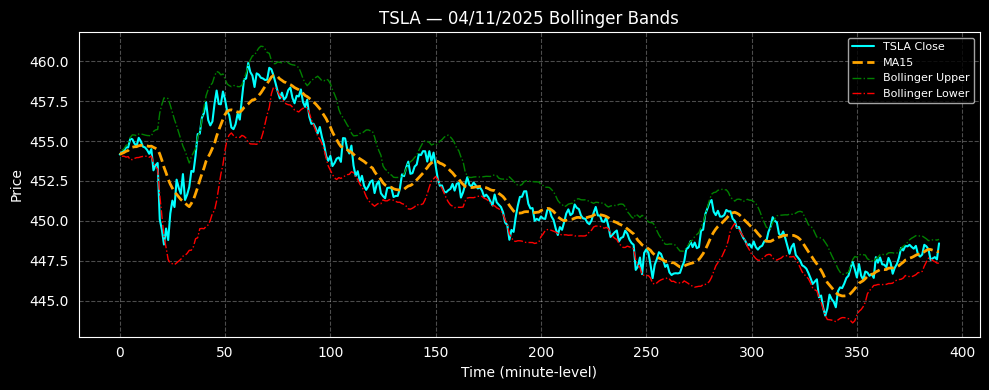

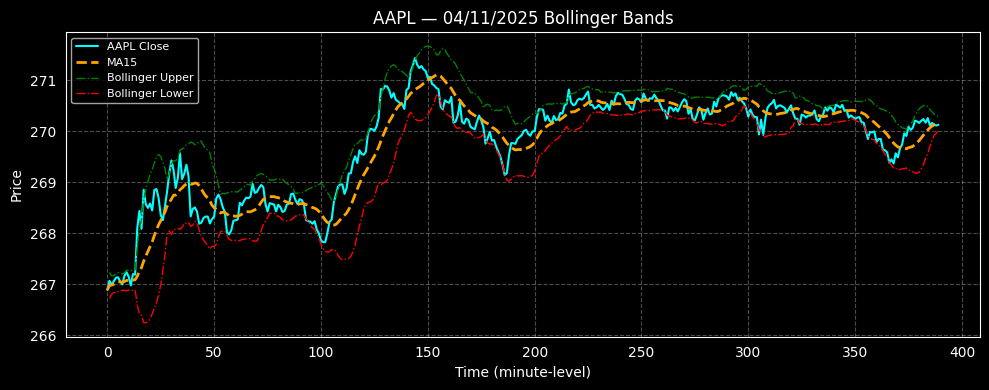

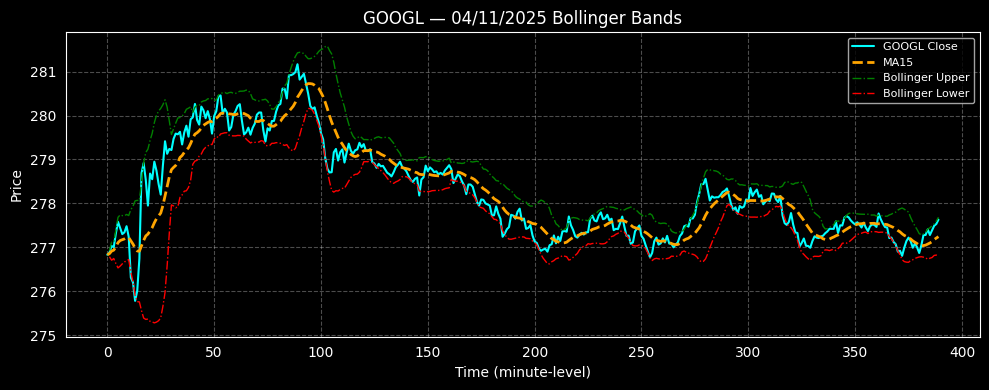

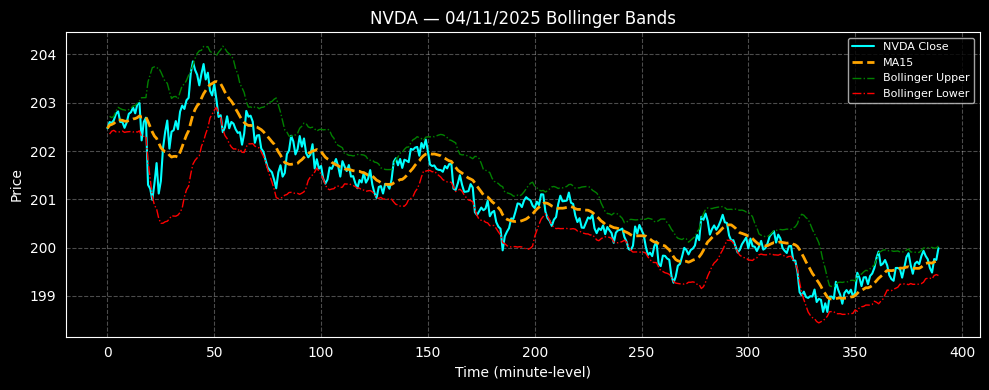

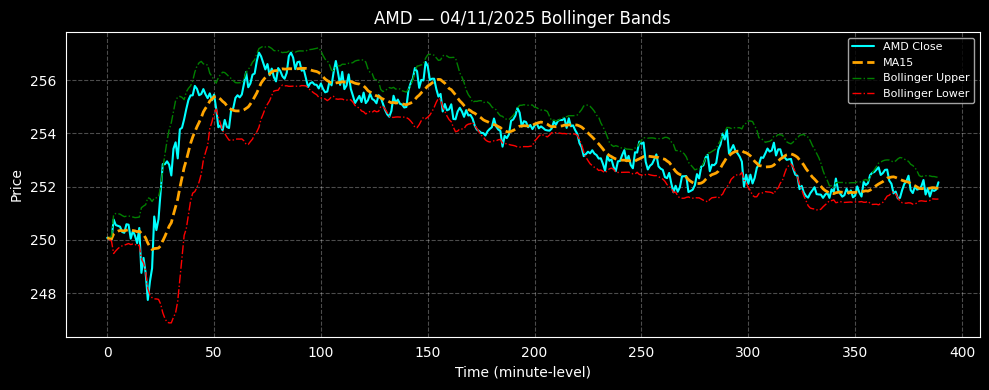

In [54]:
window = 15
tickers = ["TSLA", "AAPL", "GOOGL", "NVDA", "AMD"]

today = pd.to_datetime("2025-11-04").date()
plt.style.use("dark_background")

for ticker in tickers:
    sample = df[(df['symbol'] == ticker) & (df['start_timestamp'].dt.date == today)]
    sample = sample.sort_values('start_timestamp').drop_duplicates('start_timestamp').dropna(subset=['close'])
    
    sample['ma'] = sample['close'].rolling(window=window, min_periods=1).mean()
    sample['volatility'] = sample['close'].rolling(window=window, min_periods=1).std()
    
    sample['bollinger_upper'] = sample['ma'] + 2 * sample['volatility']
    sample['bollinger_lower'] = sample['ma'] - 2 * sample['volatility']
    
    plt.figure(figsize=(10,4))
    plt.plot(sample['close'].values, label=f"{ticker} Close", color='cyan', linewidth=1.5)
    plt.plot(sample['ma'].values, label=f"MA{window}", color='orange', linestyle='--', linewidth=2)
    plt.plot(sample['bollinger_upper'].values, label='Bollinger Upper', color='green', linestyle='-.', linewidth=1)
    plt.plot(sample['bollinger_lower'].values, label='Bollinger Lower', color='red', linestyle='-.', linewidth=1)
    
    plt.title(f"{ticker} — 04/11/2025 Bollinger Bands", color='white', fontsize=12)
    plt.xlabel("Time (minute-level)", color='white')
    plt.ylabel("Price", color='white')
    plt.legend(fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


6) Simple Strategy 2: Mean Reversion

In [63]:
window_short = 15
window_long = 60
tickers = ["TSLA", "AAPL", "GOOGL", "NVDA", "AMD"]

df['ma_short'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=window_short, min_periods=1).mean())
df['ma_long'] = df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=window_long, min_periods=1).mean())

df['signal'] = 0
for ticker in tickers:
    mask = df['symbol'] == ticker
    df.loc[mask, 'signal'] = np.where(
        df.loc[mask, 'ma_short'] > df.loc[mask, 'ma_long'], 1, -1
    )

df['strategy_return'] = df['signal'].shift(1) * df['log_return']
df['cumulative_pnl'] = df.groupby('symbol')['strategy_return'].cumsum()


In [ ]:
tickers = ["TSLA", "AAPL", "GOOGL", "NVDA", "AMD"]

performance = []

for ticker in tickers:
    sample = df[df['symbol'] == ticker].sort_values("start_timestamp").drop_duplicates("start_timestamp")
    sample = sample.dropna(subset=["close", "signal"])
    
    sample['strategy_return'] = sample['signal'].shift(1) * sample['log_return']
    sample['cumulative_pnl'] = sample['strategy_return'].cumsum()
    
    total_return = sample['cumulative_pnl'].iloc[-1]
    sharpe_ratio = sample['strategy_return'].mean() / sample['strategy_return'].std() * np.sqrt(252*390)
    max_drawdown = (sample['cumulative_pnl'].cummax() - sample['cumulative_pnl']).max()
    
    performance.append({
        'ticker': ticker,
        'total_return': total_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown
    })

performance_df = pd.DataFrame(performance)
print(performance_df)


  ticker  total_return  sharpe_ratio  max_drawdown
0   TSLA        2.5439       14.0065        0.6917
1   AAPL        1.7264       14.4614        0.1954
2  GOOGL        1.6501        9.5501        0.5010
3   NVDA        2.7034       13.0652        0.4504
4    AMD        4.5617       21.0777        0.5034


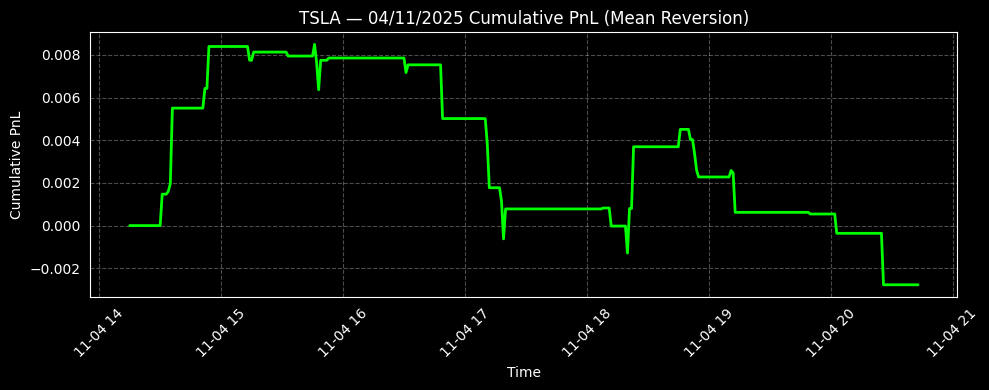

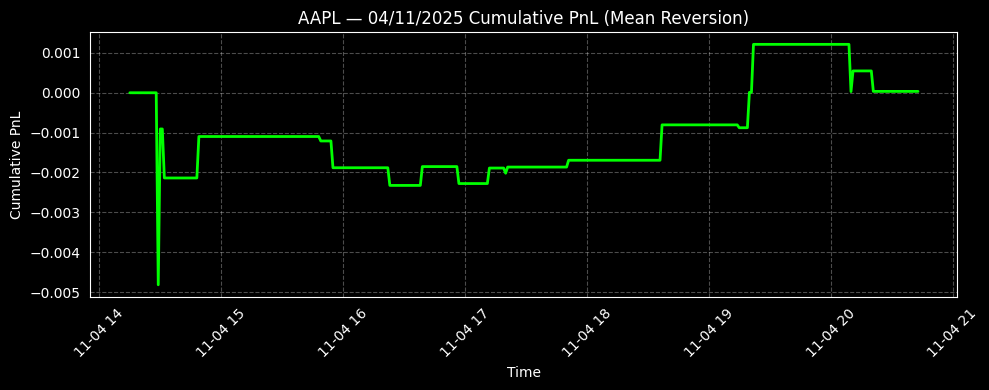

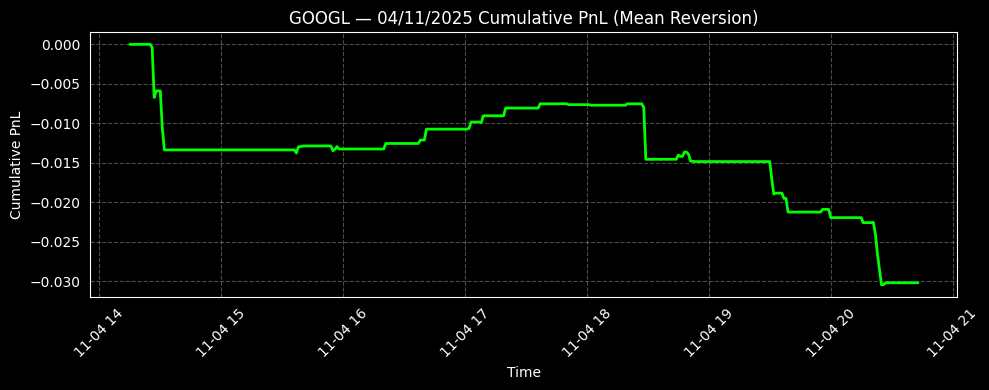

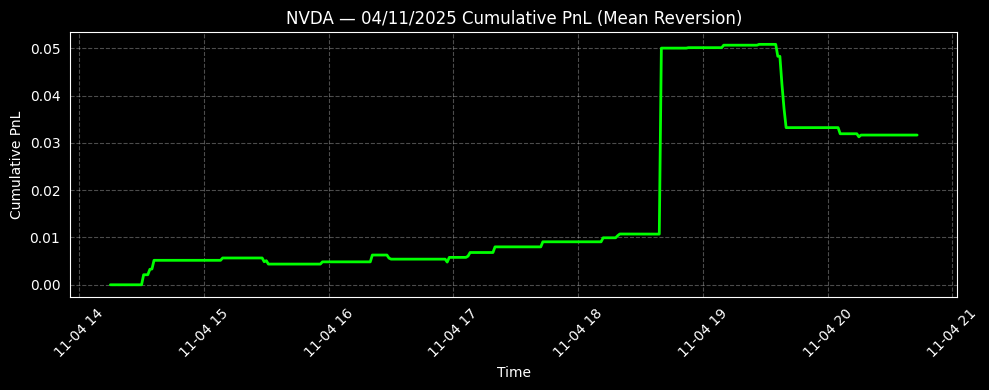

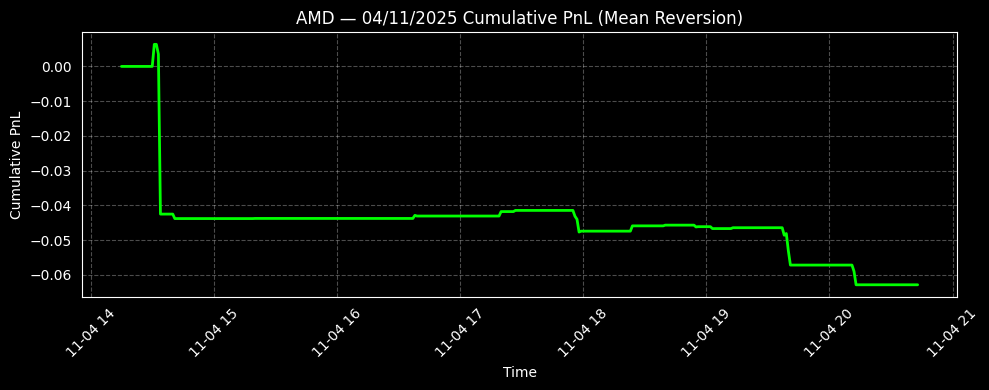

In [ ]:
window = 20
num_std = 2
tickers = ["TSLA", "AAPL", "GOOGL", "NVDA", "AMD"]

df['log_return'] = df.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1))).fillna(0)

date_focus = pd.to_datetime("2025-11-04").date()

for ticker in tickers:
    sample = df[(df['symbol'] == ticker) & (df['start_timestamp'].dt.date == date_focus)]
    sample = sample.sort_values('start_timestamp').drop_duplicates('start_timestamp')
    sample = sample.dropna(subset=['close'])
    
    rolling_mean = sample['close'].rolling(window=window, min_periods=1).mean()
    rolling_std = sample['close'].rolling(window=window, min_periods=1).std()
    
    upper_band = rolling_mean + num_std * rolling_std
    lower_band = rolling_mean - num_std * rolling_std
    
    sample['signal'] = 0
    sample.loc[sample['close'] < lower_band, 'signal'] = 1
    sample.loc[sample['close'] > upper_band, 'signal'] = -1
    
    sample['strategy_return'] = sample['signal'].shift(1) * sample['log_return']
    sample['cumulative_pnl'] = sample['strategy_return'].cumsum()
    
    plt.figure(figsize=(10,4))
    plt.plot(sample['start_timestamp'], sample['cumulative_pnl'], color='lime', linewidth=2)
    plt.title(f"{ticker} — 04/11/2025 Cumulative PnL (Mean Reversion)", color='white')
    plt.xlabel("Time", color='white')
    plt.ylabel("Cumulative PnL", color='white')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, color='white')
    plt.yticks(color='white')
    plt.tight_layout()
    plt.show()


7) Index Simulation

Top 50 Most Traded Tickers — Basic Statistics


,symbol,mean,min,max,volatility
0,AAPL,263.0499,244.2400,277.6500,8.6524
1,ADBE,342.4691,323.2800,368.0000,10.3056
2,AMD,249.5819,223.5000,266.6925,10.7156
3,AMZN,228.9906,211.1400,258.3640,13.2335
4,CSCO,71.6767,68.5200,74.8400,1.4669
5,GOOGL,267.3169,246.1700,295.5800,11.9986
6,INTC,38.9750,35.0000,42.4300,1.7282
7,META,703.2199,627.1900,757.9400,44.8238
8,MSFT,522.9991,506.9500,556.4350,10.7356
9,NFLX,1117.3756,1074.2700,1216.4300,36.5994


Portfolio Sharpe Ratio: 11.21
Portfolio Max Drawdown: 0.87


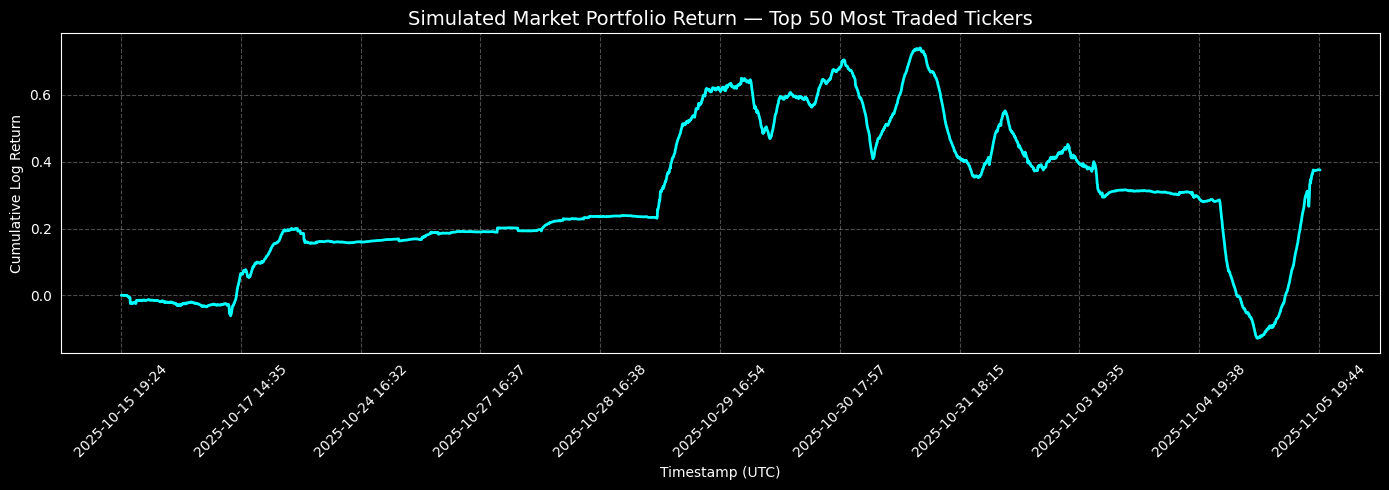

In [90]:
tickers_count = df.groupby('symbol')['start_timestamp'].count().reset_index().rename(columns={'start_timestamp':'data_points'})
top_tickers = tickers_count.sort_values('data_points', ascending=False).head(50)['symbol'].tolist()

stats = df.groupby('symbol')['close'].agg(['mean','min','max','std']).reset_index().rename(columns={'std':'volatility'})
top_tickers_stats = stats[stats['symbol'].isin(top_tickers)]
print("Top 50 Most Traded Tickers — Basic Statistics")
display(top_tickers_stats)


df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1))
df['log_return'] = df['log_return'].fillna(0)


portfolio_returns = []
for ticker in top_tickers:
    sample = df[df['symbol'] == ticker].sort_values('start_timestamp').drop_duplicates('start_timestamp')
    sample = sample.dropna(subset=['log_return', 'start_timestamp'])
    s = sample.set_index('start_timestamp')['log_return']
    portfolio_returns.append(s)

common_index = portfolio_returns[0].index
for s in portfolio_returns[1:]:
    common_index = common_index.intersection(s.index)


portfolio_returns_aligned = [s.loc[common_index] for s in portfolio_returns]


portfolio_returns_df = pd.concat(portfolio_returns_aligned, axis=1)
portfolio_returns_df.columns = top_tickers
portfolio_returns_df['portfolio_return'] = portfolio_returns_df.mean(axis=1)
portfolio_returns_df['cumulative_return'] = portfolio_returns_df['portfolio_return'].cumsum()

sharpe_ratio = portfolio_returns_df['portfolio_return'].mean() / portfolio_returns_df['portfolio_return'].std() * np.sqrt(252*390) # 390 min par jour
max_drawdown = (portfolio_returns_df['cumulative_return'].cummax() - portfolio_returns_df['cumulative_return']).max()

print(f"Portfolio Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Portfolio Max Drawdown: {max_drawdown:.2f}")

plt.style.use("dark_background")
plt.figure(figsize=(14,5))
plt.plot(range(len(portfolio_returns_df)), portfolio_returns_df['cumulative_return'], color='cyan', linewidth=2)
x_labels = [ts.strftime('%Y-%m-%d %H:%M') for ts in portfolio_returns_df.index[::max(1,len(portfolio_returns_df)//10)]]
plt.xticks(range(0,len(portfolio_returns_df), max(1,len(portfolio_returns_df)//10)), x_labels, rotation=45, color="white")
plt.yticks(color="white")
plt.grid(True, linestyle="--", alpha=0.3)
plt.title("Simulated Market Portfolio Return — Top 50 Most Traded Tickers", color="white", fontsize=14)
plt.xlabel("Timestamp (UTC)", color="white")
plt.ylabel("Cumulative Log Return", color="white")
plt.tight_layout()
plt.show()


8) Monte Carlo Basic Simulation & Backtest

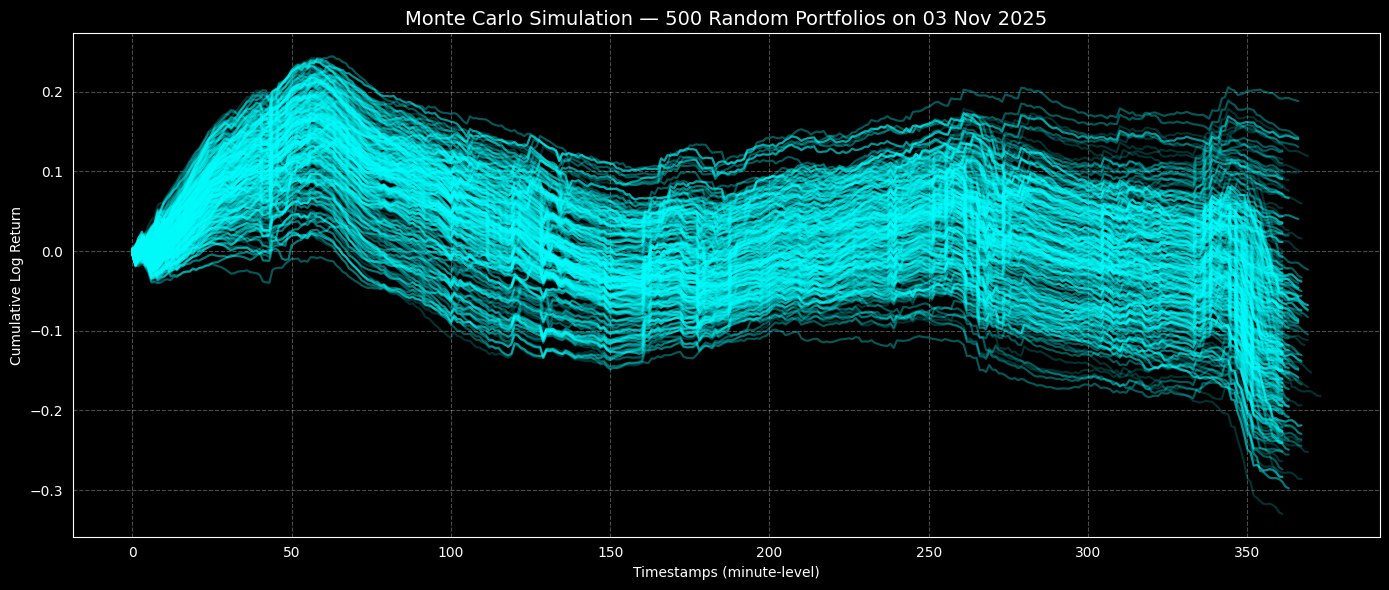

In [92]:
df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1)).fillna(0)

date_of_interest = pd.to_datetime("2025-11-03").date()
df_day = df[df['start_timestamp'].dt.date == date_of_interest]

tickers_count = df_day.groupby('symbol')['start_timestamp'].count().reset_index().rename(columns={'start_timestamp':'data_points'})
top_tickers = tickers_count.sort_values('data_points', ascending=False).head(50)['symbol'].tolist()

n_portfolios = 500
cumulative_portfolios = []

for _ in range(n_portfolios):
    sampled_tickers = np.random.choice(top_tickers, size=10, replace=False)
    returns_list = []
    for ticker in sampled_tickers:
        sample = df_day[df_day['symbol'] == ticker].sort_values('start_timestamp').drop_duplicates('start_timestamp')
        sample = sample.dropna(subset=['log_return', 'start_timestamp'])
        returns_list.append(sample.set_index('start_timestamp')['log_return'])
    
    common_index = returns_list[0].index
    for s in returns_list[1:]:
        common_index = common_index.intersection(s.index)
    
    aligned_returns = [s.loc[common_index] for s in returns_list]
    portfolio_df = pd.concat(aligned_returns, axis=1)
    portfolio_df['portfolio_return'] = portfolio_df.mean(axis=1)
    portfolio_df['cumulative_return'] = portfolio_df['portfolio_return'].cumsum()
    cumulative_portfolios.append(portfolio_df['cumulative_return'].values)

plt.style.use("dark_background")
plt.figure(figsize=(14,6))
for cum_ret in cumulative_portfolios:
    plt.plot(cum_ret, color='cyan', alpha=0.2)
plt.title("Monte Carlo Simulation — 500 Random Portfolios on 03 Nov 2025", color="white", fontsize=14)
plt.xlabel("Timestamps (minute-level)", color="white")
plt.ylabel("Cumulative Log Return", color="white")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


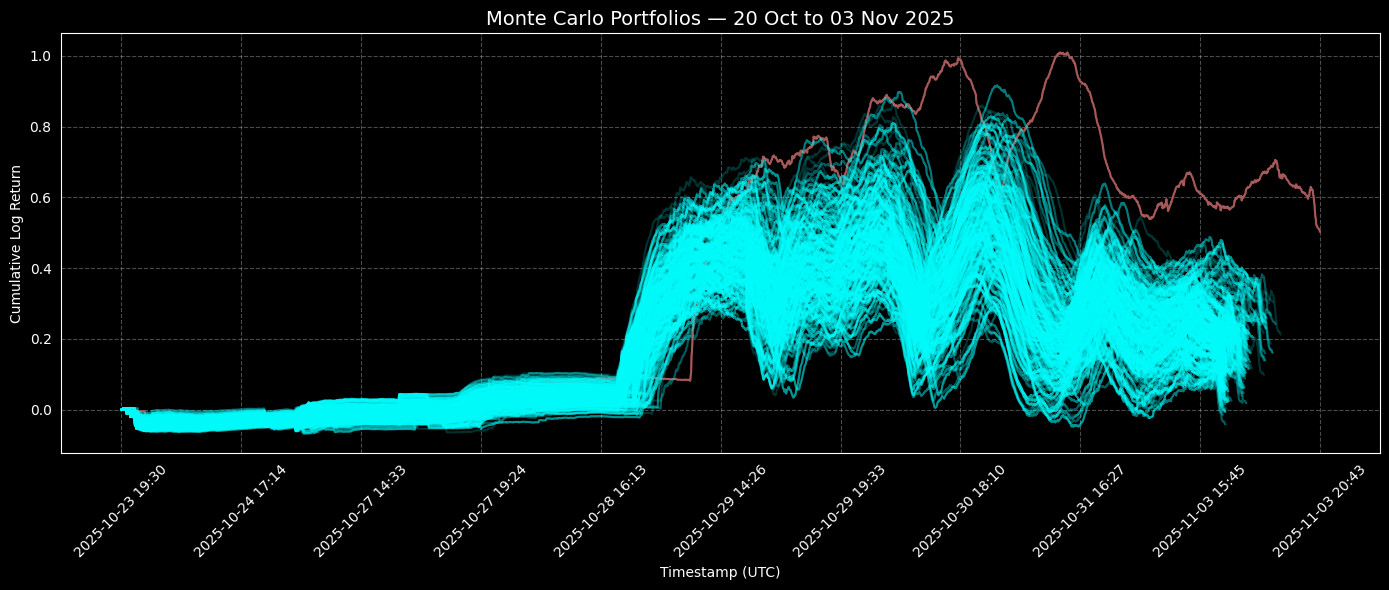

Best portfolio tickers: ['INTC' 'GOOGL' 'AMZN' 'TSLA' 'META' 'AMD' 'PYPL' 'MSFT' 'NVDA' 'AAPL']
Final cumulative return: 0.502429355930431


In [96]:
df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1)).fillna(0)

start_date = pd.to_datetime("2025-10-20").date()
end_date = pd.to_datetime("2025-11-03").date()
df_period = df[(df['start_timestamp'].dt.date >= start_date) &
               (df['start_timestamp'].dt.date <= end_date)]

tickers_count = df_period.groupby('symbol')['start_timestamp'].count().reset_index().rename(columns={'start_timestamp':'data_points'})
top_tickers = tickers_count.sort_values('data_points', ascending=False).head(50)['symbol'].tolist()

n_portfolios = 500
portfolio_cum_returns = []
portfolio_tickers_list = []

for _ in range(n_portfolios):
    sampled_tickers = np.random.choice(top_tickers, size=10, replace=False)
    returns_list = []
    for ticker in sampled_tickers:
        sample = df_period[df_period['symbol'] == ticker].sort_values('start_timestamp').drop_duplicates('start_timestamp')
        sample = sample.dropna(subset=['log_return', 'start_timestamp'])
        returns_list.append(sample.set_index('start_timestamp')['log_return'])
    
    common_index = returns_list[0].index
    for s in returns_list[1:]:
        common_index = common_index.intersection(s.index)
    
    aligned_returns = [s.loc[common_index] for s in returns_list]
    portfolio_df = pd.concat(aligned_returns, axis=1)
    portfolio_df['portfolio_return'] = portfolio_df.mean(axis=1)
    portfolio_df['cumulative_return'] = portfolio_df['portfolio_return'].cumsum()
    
    portfolio_cum_returns.append(portfolio_df['cumulative_return'])
    portfolio_tickers_list.append(sampled_tickers)

final_returns = [cum_ret.iloc[-1] for cum_ret in portfolio_cum_returns]
best_idx = np.argmax(final_returns)
best_portfolio_cum = portfolio_cum_returns[best_idx]
best_portfolio_tickers = portfolio_tickers_list[best_idx]

plt.style.use("dark_background")
plt.figure(figsize=(14,6))

for i, cum_ret in enumerate(portfolio_cum_returns):
    color = 'red' if i == best_idx else 'cyan'
    alpha = 1.0 if i == best_idx else 0.2
    plt.plot(range(len(cum_ret)), cum_ret, color=color, alpha=alpha)

x_labels = [ts.strftime('%Y-%m-%d %H:%M') for ts in best_portfolio_cum.index[::max(1,len(best_portfolio_cum)//10)]]
plt.xticks(range(0,len(best_portfolio_cum), max(1,len(best_portfolio_cum)//10)), x_labels, rotation=45, color="white")
plt.yticks(color="white")
plt.grid(True, linestyle="--", alpha=0.3)
plt.title(f"Monte Carlo Portfolios — 20 Oct to 03 Nov 2025", color="white", fontsize=14)
plt.xlabel("Timestamp (UTC)", color="white")
plt.ylabel("Cumulative Log Return", color="white")
plt.tight_layout()
plt.show()

print("Best portfolio tickers:", best_portfolio_tickers)
print("Final cumulative return:", best_portfolio_cum.iloc[-1])


In [93]:
df['log_return'] = np.log(df['close'] / df.groupby('symbol')['close'].shift(1)).fillna(0)

date_mc = pd.to_datetime("2025-10-03").date()
date_bt = pd.to_datetime("2025-11-04").date()

df_mc = df[df['start_timestamp'].dt.date == date_mc]
df_bt = df[df['start_timestamp'].dt.date == date_bt]

tickers_count = df_mc.groupby('symbol')['start_timestamp'].count().reset_index().rename(columns={'start_timestamp':'data_points'})
top_tickers = tickers_count.sort_values('data_points', ascending=False).head(50)['symbol'].tolist()

n_portfolios = 500
portfolio_results = []

for i in range(n_portfolios):
    sampled_tickers = np.random.choice(top_tickers, size=10, replace=False)
    
    returns_list_bt = []
    for ticker in sampled_tickers:
        sample_bt = df_bt[df_bt['symbol'] == ticker].sort_values('start_timestamp').drop_duplicates('start_timestamp')
        sample_bt = sample_bt.dropna(subset=['log_return', 'start_timestamp'])
        returns_list_bt.append(sample_bt.set_index('start_timestamp')['log_return'])
    
    if len(returns_list_bt) == 0:
        continue
    
    common_index_bt = returns_list_bt[0].index
    for s in returns_list_bt[1:]:
        common_index_bt = common_index_bt.intersection(s.index)
    
    aligned_returns_bt = [s.loc[common_index_bt] for s in returns_list_bt]
    portfolio_df_bt = pd.concat(aligned_returns_bt, axis=1)
    portfolio_df_bt['portfolio_return'] = portfolio_df_bt.mean(axis=1)
    portfolio_df_bt['cumulative_return'] = portfolio_df_bt['portfolio_return'].cumsum()
    
    portfolio_results.append({
        'portfolio_id': i,
        'tickers': sampled_tickers,
        'cumulative_return': portfolio_df_bt['cumulative_return'].iloc[-1] if not portfolio_df_bt.empty else np.nan
    })

results_df = pd.DataFrame(portfolio_results).dropna().sort_values('cumulative_return', ascending=False).reset_index(drop=True)
top_10_portfolios = results_df.head(10)
top_10_portfolios


,portfolio_id,tickers,cumulative_return
0,71,"[ADBE, NVDA, GOOGL, AMD, NFLX, TSLA, MSFT, AMZ...",0.0161
1,443,"[GOOGL, CSCO, INTC, AMZN, TSLA, AMD, NFLX, ADB...",0.0153
2,312,"[MSFT, AMZN, GOOGL, AAPL, ADBE, NVDA, NFLX, IN...",0.0150
3,499,"[GOOGL, INTC, NFLX, MSFT, TSLA, NVDA, AMZN, AD...",0.0150
4,80,"[CSCO, AMD, TSLA, AMZN, GOOGL, NVDA, AAPL, NFL...",0.0122
5,190,"[TSLA, MSFT, NVDA, NFLX, ADBE, PYPL, GOOGL, AA...",0.0122
6,48,"[NVDA, AMD, AAPL, TSLA, ADBE, CSCO, MSFT, INTC...",0.0115
7,114,"[ADBE, NVDA, MSFT, INTC, AMZN, AMD, AAPL, TSLA...",0.0115
8,378,"[INTC, MSFT, AMZN, CSCO, TSLA, ADBE, NFLX, AAP...",0.0115
9,198,"[AAPL, ADBE, TSLA, MSFT, NFLX, INTC, AMD, CSCO...",0.0115


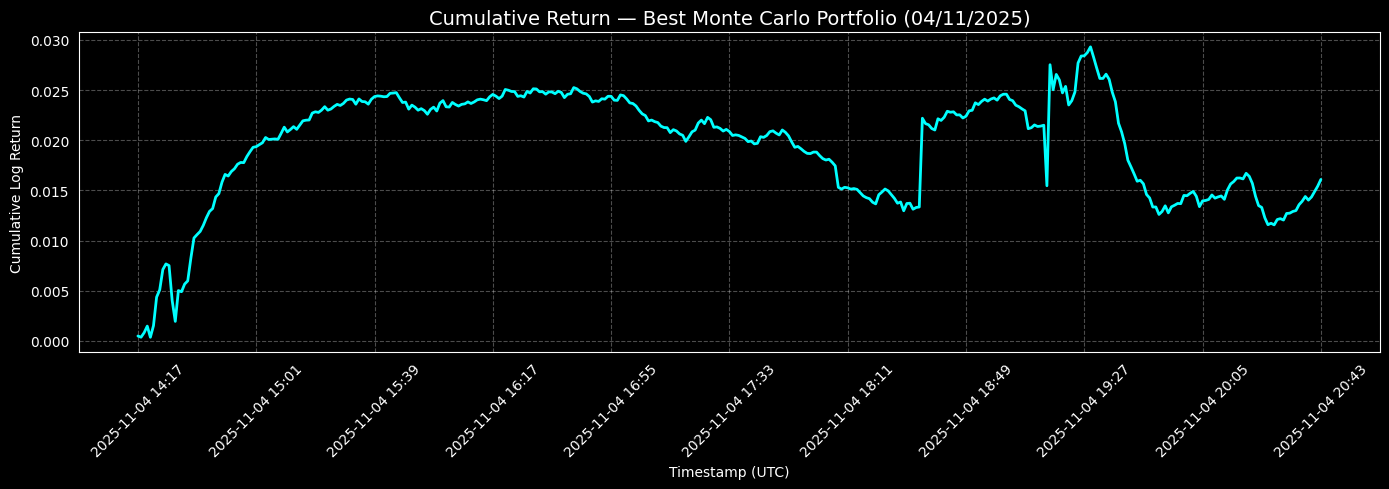

In [94]:
best_portfolio = top_10_portfolios.iloc[0]['tickers']

returns_list_bt = []
for ticker in best_portfolio:
    sample_bt = df_bt[df_bt['symbol'] == ticker].sort_values('start_timestamp').drop_duplicates('start_timestamp')
    sample_bt = sample_bt.dropna(subset=['log_return', 'start_timestamp'])
    returns_list_bt.append(sample_bt.set_index('start_timestamp')['log_return'])

common_index_bt = returns_list_bt[0].index
for s in returns_list_bt[1:]:
    common_index_bt = common_index_bt.intersection(s.index)

aligned_returns_bt = [s.loc[common_index_bt] for s in returns_list_bt]
portfolio_df_bt = pd.concat(aligned_returns_bt, axis=1)
portfolio_df_bt['portfolio_return'] = portfolio_df_bt.mean(axis=1)
portfolio_df_bt['cumulative_return'] = portfolio_df_bt['portfolio_return'].cumsum()

plt.style.use("dark_background")
plt.figure(figsize=(14,5))
plt.plot(range(len(portfolio_df_bt)), portfolio_df_bt['cumulative_return'], color='cyan', linewidth=2)
x_labels = [ts.strftime('%Y-%m-%d %H:%M') for ts in portfolio_df_bt.index[::max(1,len(portfolio_df_bt)//10)]]
plt.xticks(range(0,len(portfolio_df_bt), max(1,len(portfolio_df_bt)//10)), x_labels, rotation=45, color="white")
plt.yticks(color="white")
plt.grid(True, linestyle="--", alpha=0.3)
plt.title("Cumulative Return — Best Monte Carlo Portfolio (04/11/2025)", color="white", fontsize=14)
plt.xlabel("Timestamp (UTC)", color="white")
plt.ylabel("Cumulative Log Return", color="white")
plt.tight_layout()
plt.show()
